# Unit08 化工案例六：填充吸收塔傳遞單位數與塔高計算

> **學習目標**
> 1. 理解氣體吸收塔設計中整體傳遞單位數（ $N_{OG}$ ）與塔高（ $H$ ）的計算原理。
> 2. 使用 `numpy.polyfit()` 對溶解度平衡數據進行多項式擬合，建立平衡關係式 $y^*(x)$ 。
> 3. 掌握操作線方程式的推導與最小液氣比（ $(L/G)_{\min}$ ）的計算方法。
> 4. 使用 `scipy.integrate.quad()` 計算含插值函數之積分 $N_{OG} = \int_{y_2}^{y_1} \frac{dy}{y - y^*(x(y))}$ 。
> 5. 探討液氣比對傳遞單位數與填充塔高度的影響，進行工程設計敏感度分析。

---
### 0. 環境設定

In [9]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit08_Example_06'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit08'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit08
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Example_06
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Example_06\figs


---
### 1. 載入套件

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from scipy.integrate import quad
from scipy.optimize import brentq

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
import scipy
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題設定與平衡曲線擬合

**系統**：SO₂ 氣體以清水（純溶劑）為吸收劑，在填充塔中進行逆流氣液接觸吸收。

**操作條件**

| 參數 | 數值 | 單位 | 說明 |
|:---|:---:|:---:|:---|
| 進塔氣體 SO₂ 莫耳分率 | $y_1 = 0.060$ | — | 塔底進氣組成（氣體進料） |
| 出塔氣體 SO₂ 莫耳分率 | $y_2 = 0.005$ | — | 塔頂出氣組成（吸收目標） |
| 進塔溶劑 SO₂ 莫耳分率 | $x_2 = 0.000$ | — | 塔頂進液為純水 |
| 整體氣相傳遞單位高度 | $H_{OG} = 0.80$ | m | 填充物特性參數 |

**溶解度平衡數據**（SO₂–水系統，30°C，1 atm）

| $x$ （液相 SO₂ 莫耳分率） | 0.000 | 0.001 | 0.002 | 0.003 | 0.004 | 0.005 |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| $y^*$ （平衡氣相 SO₂ 莫耳分率） | 0.000 | 0.014 | 0.030 | 0.048 | 0.068 | 0.090 |

> 以 `numpy.polyfit()` 對上述數據進行**二次多項式**擬合，建立連續的平衡關係式 $y^*(x)$ ，供後續積分使用。

In [11]:
# ================================================================
# 操作條件
# ================================================================
y1   = 0.060   # 塔底進氣 SO₂ 莫耳分率（氣體進料）
y2   = 0.005   # 塔頂出氣 SO₂ 莫耳分率（吸收目標）
x2   = 0.000   # 塔頂進液溶劑（純水），SO₂ 莫耳分率為 0
H_OG = 0.80    # 整體氣相傳遞單位高度 (m)

# ================================================================
# 溶解度平衡數據 (SO₂–水系統，30°C，1 atm)
# ================================================================
x_eq = np.array([0.000, 0.001, 0.002, 0.003, 0.004, 0.005])   # 液相莫耳分率
y_eq = np.array([0.000, 0.014, 0.030, 0.048, 0.068, 0.090])   # 氣相平衡莫耳分率

# ================================================================
# 二次多項式擬合平衡曲線：y* = p[0]*x² + p[1]*x + p[2]
# ================================================================
poly_deg = 2
p_coeffs = np.polyfit(x_eq, y_eq, poly_deg)
print(f"平衡曲線多項式係數（降冪排列）:")
print(f"  p[0] (x² 係數) = {p_coeffs[0]:.4f}")
print(f"  p[1] (x  係數) = {p_coeffs[1]:.4f}")
print(f"  p[2] (常數項)  = {p_coeffs[2]:.6f}")

# 建立可呼叫的平衡函數
def y_star(x_val):
    """平衡氣相濃度 y* = f(x)，由二次多項式擬合"""
    return np.polyval(p_coeffs, x_val)

# 驗算：與原始數據比較
print("\n平衡曲線擬合驗算（原始數據 vs 多項式預測）：")
print(f"{'x':>8}  {'y*(原始)':>10}  {'y*(擬合)':>10}  {'誤差':>10}")
for xi, yi in zip(x_eq, y_eq):
    y_fit = y_star(xi)
    print(f"{xi:8.4f}  {yi:10.4f}  {y_fit:10.6f}  {abs(yi - y_fit):10.6f}")

平衡曲線多項式係數（降冪排列）:
  p[0] (x² 係數) = 1000.0000
  p[1] (x  係數) = 13.0000
  p[2] (常數項)  = -0.000000

平衡曲線擬合驗算（原始數據 vs 多項式預測）：
       x      y*(原始)      y*(擬合)          誤差
  0.0000      0.0000   -0.000000    0.000000
  0.0010      0.0140    0.014000    0.000000
  0.0020      0.0300    0.030000    0.000000
  0.0030      0.0480    0.048000    0.000000
  0.0040      0.0680    0.068000    0.000000
  0.0050      0.0900    0.090000    0.000000


---
### 3. 操作線分析與最小液氣比

**操作線方程式**（稀溶液近似，以莫耳分率表示）：

$$
y = \frac{L}{G}(x - x_2) + y_2
$$

其中 $L/G$ 為液氣莫耳流率比。由操作線反求液相濃度：

$$
x(y) = \frac{(y - y_2)}{L/G} + x_2
$$

**最小液氣比 $(L/G)_{\min}$** 發生條件：塔底操作點 $(x_1, y_1)$ 落在平衡曲線上（氣液達到平衡，驅動力為零）。

$$
\left(\frac{L}{G}\right)_{\min} = \frac{y_1 - y_2}{x_{1,eq} - x_2}
$$

其中 $x_{1,eq}$ 滿足 $y^*(x_{1,eq}) = y_1$ ，由求根法（`scipy.optimize.brentq`）求解。

**設計液氣比**：通常取 $L/G = 1.5 \times (L/G)_{\min}$ 。

In [12]:
# ================================================================
# 最小液氣比計算
# ================================================================
# 求 x_{1,eq}：使得 y*(x_{1,eq}) = y1（塔底氣液平衡點）
# 即求解 y_star(x) - y1 = 0
x1_eq = brentq(lambda x: y_star(x) - y1, 1e-6, 0.010)
LG_min = (y1 - y2) / (x1_eq - x2)

print("=" * 50)
print("最小液氣比分析")
print("=" * 50)
print(f"  塔底平衡液相濃度 x_{{1,eq}} = {x1_eq:.6f}")
print(f"  (L/G)_min               = {LG_min:.4f}")

# ================================================================
# 設計液氣比（取 1.5 倍最小值）
# ================================================================
design_factor = 1.5
LG_design = design_factor * LG_min
x1_design = (y1 - y2) / LG_design + x2   # 塔底液相出口組成

print(f"\n設計液氣比（設計因子 = {design_factor}）")
print(f"  (L/G)_design = {design_factor} × {LG_min:.4f} = {LG_design:.4f}")
print(f"  塔底液相出口組成 x_1 = {x1_design:.6f}")

# 操作線函數
def x_from_y(y_val, LG):
    """由氣相組成 y 計算操作線對應液相組成 x"""
    return (y_val - y2) / LG + x2

print(f"\n操作線驗算（設計 L/G = {LG_design:.4f}）：")
print(f"  塔頂：y2 = {y2:.3f}, x2 = {x_from_y(y2, LG_design):.6f}（應 ≈ {x2}）")
print(f"  塔底：y1 = {y1:.3f}, x1 = {x_from_y(y1, LG_design):.6f}")

最小液氣比分析
  塔底平衡液相濃度 x_{1,eq} = 0.003612
  (L/G)_min               = 15.2276

設計液氣比（設計因子 = 1.5）
  (L/G)_design = 1.5 × 15.2276 = 22.8413
  塔底液相出口組成 x_1 = 0.002408

操作線驗算（設計 L/G = 22.8413）：
  塔頂：y2 = 0.005, x2 = 0.000000（應 ≈ 0.0）
  塔底：y1 = 0.060, x1 = 0.002408


---
### 4. 傳遞單位數 $N_{OG}$ 計算與塔高 $H$

**整體氣相傳遞單位數**：

$$
N_{OG} = \int_{y_2}^{y_1} \frac{dy}{y - y^*(x(y))}
$$

被積分函數中：
- $y^*(x)$ ：由多項式擬合的平衡關係式
- $x(y)$ ：由操作線方程式求得：$x = (y - y_2)/(L/G) + x_2$

兩式組合後，被積分函數為 $y$ 的函數，可直接使用 `scipy.integrate.quad()` 求定積分。

**填充塔高度**：

$$
H = N_{OG} \times H_{OG}
$$

In [13]:
# ================================================================
# N_OG 積分計算（設計 L/G）
# ================================================================
def integrand_NOG(y_val, LG):
    """被積分函數 1/(y - y*(x(y)))"""
    x_val = x_from_y(y_val, LG)          # 操作線：由 y 求 x
    y_star_val = y_star(x_val)            # 平衡關係：由 x 求 y*
    driving_force = y_val - y_star_val   # 氣相推動力
    return 1.0 / driving_force

# 計算 N_OG（設計 L/G）
N_OG_design, err_design = quad(integrand_NOG, y2, y1, args=(LG_design,))
H_design = N_OG_design * H_OG

print("=" * 55)
print(f"傳遞單位數與塔高計算結果（L/G = {LG_design:.4f}）")
print("=" * 55)
print(f"  整體氣相傳遞單位數 N_OG = {N_OG_design:.4f}")
print(f"  積分誤差估計          = {err_design:.2e}")
print(f"  整體傳遞單位高度 H_OG  = {H_OG:.2f} m")
print(f"  填充塔高度 H           = N_OG × H_OG")
print(f"                        = {N_OG_design:.4f} × {H_OG:.2f}")
print(f"                        = {H_design:.4f} m")

# ================================================================
# 驅動力分布（逐點輸出，理解積分被積函數分布）
# ================================================================
print(f"\n各 y 值之驅動力分析（L/G = {LG_design:.4f}）：")
print(f"{'y':>8}  {'x(y)':>10}  {'y*(x)':>10}  {'y-y*':>10}  {'1/(y-y*)':>12}")
y_check = np.linspace(y2, y1, 12)
for y_v in y_check:
    x_v = x_from_y(y_v, LG_design)
    ystar_v = y_star(x_v)
    df = y_v - ystar_v
    print(f"{y_v:8.4f}  {x_v:10.6f}  {ystar_v:10.6f}  {df:10.6f}  {1/df:12.4f}")

傳遞單位數與塔高計算結果（L/G = 22.8413）
  整體氣相傳遞單位數 N_OG = 4.3374
  積分誤差估計          = 6.42e-12
  整體傳遞單位高度 H_OG  = 0.80 m
  填充塔高度 H           = N_OG × H_OG
                        = 4.3374 × 0.80
                        = 3.4699 m

各 y 值之驅動力分析（L/G = 22.8413）：
       y        x(y)       y*(x)        y-y*      1/(y-y*)
  0.0050    0.000000   -0.000000    0.005000      200.0000
  0.0100    0.000219    0.002894    0.007106      140.7190
  0.0150    0.000438    0.005883    0.009117      109.6865
  0.0200    0.000657    0.008968    0.011032       90.6488
  0.0250    0.000876    0.012150    0.012850       77.8184
  0.0300    0.001095    0.015427    0.014573       68.6179
  0.0350    0.001313    0.018799    0.016201       61.7259
  0.0400    0.001532    0.022268    0.017732       56.3952
  0.0450    0.001751    0.025832    0.019168       52.1716
  0.0500    0.001970    0.029493    0.020507       48.7634
  0.0550    0.002189    0.033249    0.021751       45.9748
  0.0600    0.002408    0.037101    0.022899 

---
### 5. 液氣比對 $N_{OG}$ 與塔高的影響（敏感度分析）

探討不同 $L/G$ 倍數（從 $1.1 \times (L/G)_{\min}$ 到 $3.0 \times (L/G)_{\min}$ ）對以下指標的影響：
- 整體氣相傳遞單位數 $N_{OG}$
- 填充塔高度 $H = N_{OG} \times H_{OG}$

In [14]:
# ================================================================
# 液氣比敏感度分析
# ================================================================
factors = np.linspace(1.1, 3.0, 20)        # L/G = factor × LG_min
LG_range   = factors * LG_min
N_OG_list  = []
H_list     = []

for LG in LG_range:
    try:
        N_val, _ = quad(integrand_NOG, y2, y1, args=(LG,), limit=200)
        N_OG_list.append(N_val)
        H_list.append(N_val * H_OG)
    except Exception:
        N_OG_list.append(np.nan)
        H_list.append(np.nan)

N_OG_arr = np.array(N_OG_list)
H_arr    = np.array(H_list)

# 列印部分結果
print(f"{'倍數 (×LG_min)':>16} {'L/G':>10} {'N_OG':>10} {'H (m)':>10}")
print("-" * 50)
for fac, LG, N, H in zip(factors, LG_range, N_OG_arr, H_arr):
    print(f"{fac:16.2f} {LG:10.4f} {N:10.4f} {H:10.4f}")

print(f"\n※ 設計點（{design_factor}×LG_min）：N_OG = {N_OG_design:.4f}, H = {H_design:.4f} m")

    倍數 (×LG_min)        L/G       N_OG      H (m)
--------------------------------------------------
            1.10    16.7503     7.3981     5.9185
            1.20    18.2731     5.8721     4.6977
            1.30    19.7958     5.1201     4.0961
            1.40    21.3186     4.6563     3.7251
            1.50    22.8413     4.3374     3.4699
            1.60    24.3641     4.1031     3.2824
            1.70    25.8868     3.9229     3.1383
            1.80    27.4096     3.7796     3.0237
            1.90    28.9323     3.6629     2.9303
            2.00    30.4551     3.5658     2.8526
            2.10    31.9779     3.4837     2.7870
            2.20    33.5006     3.4134     2.7307
            2.30    35.0234     3.3524     2.6819
            2.40    36.5461     3.2990     2.6392
            2.50    38.0689     3.2519     2.6015
            2.60    39.5916     3.2100     2.5680
            2.70    41.1144     3.1724     2.5379
            2.80    42.6371     3.1386     2.5109

---
### 6. 圖形輸出

程式共輸出三張子圖（Fig 1–3），整合為一張橫向排列圖形：

- **Fig 1**：$y$–$x$ 相圖（Equilibrium Curve & Operating Lines）
- **Fig 2**：被積分函數 $1/(y - y^*)$ 對 $y$ 的分布曲線（N_OG Integrand）
- **Fig 3**：液氣比敏感度分析（$N_{OG}$ 與 $H$ 隨 $L/G$ 的變化）

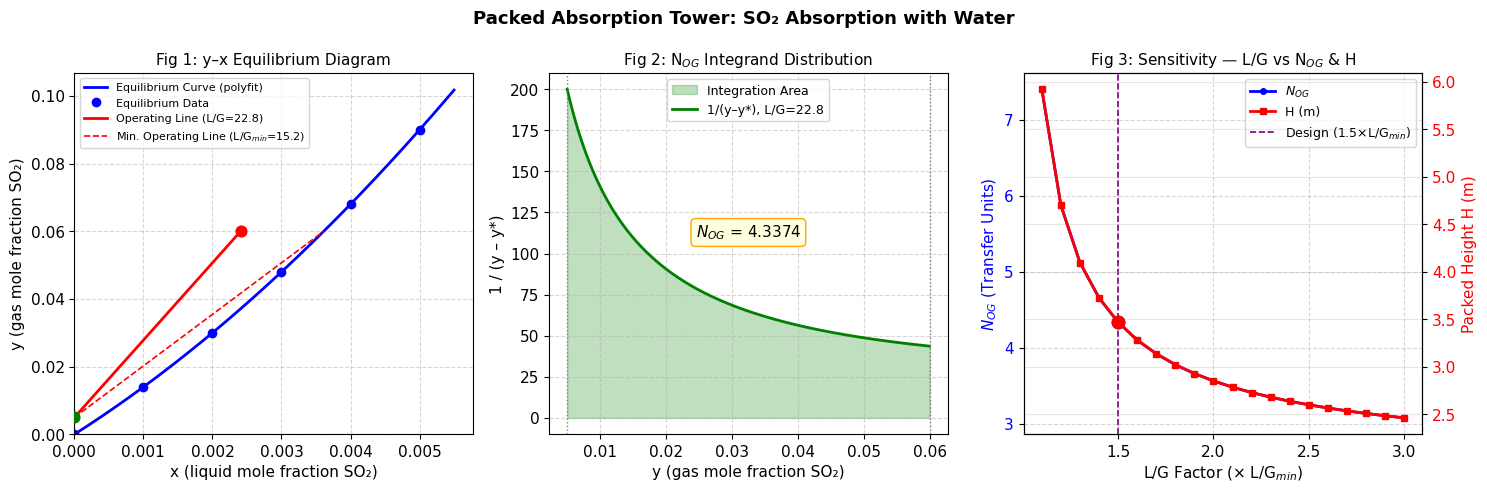


✓ 圖形已儲存至: d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Example_06\figs\Fig1_3_Absorption_Tower.png


In [15]:
# ================================================================
# 圖形繪製
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Packed Absorption Tower: SO₂ Absorption with Water", fontsize=13, fontweight='bold')

# ----------------------------------------------------------------
# Fig 1：y–x Equilibrium Diagram
# ----------------------------------------------------------------
ax1 = axes[0]
x_plot = np.linspace(0, 0.0055, 300)
y_eq_plot = y_star(x_plot)

# Minimum operating line
x1_min_op = x1_eq
y_min_op_line = np.array([x2, x1_min_op])
y_min_op_vals = np.array([y2, y1])

# Design operating line
x1_des = x_from_y(y1, LG_design)
x_op_des = np.array([x2, x1_des])
y_op_des = np.array([y2, y1])

ax1.plot(x_plot, y_eq_plot, 'b-', linewidth=2, label='Equilibrium Curve (polyfit)')
ax1.plot(x_eq, y_eq, 'bo', markersize=6, label='Equilibrium Data')
ax1.plot(x_op_des, y_op_des, 'r-', linewidth=2,
         label=f'Operating Line (L/G={LG_design:.1f})')
ax1.plot(y_min_op_line, y_min_op_vals, 'r--', linewidth=1.2,
         label=f'Min. Operating Line (L/G$_{{min}}$={LG_min:.1f})')
ax1.scatter([x1_des], [y1], color='red', s=60, zorder=5)
ax1.scatter([x2], [y2], color='green', s=60, zorder=5)
ax1.set_xlabel('x (liquid mole fraction SO₂)', fontsize=11)
ax1.set_ylabel('y (gas mole fraction SO₂)', fontsize=11)
ax1.set_title('Fig 1: y–x Equilibrium Diagram', fontsize=11)
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

# ----------------------------------------------------------------
# Fig 2：N_OG Integrand 1/(y–y*) vs y
# ----------------------------------------------------------------
ax2 = axes[1]
y_int_plot = np.linspace(y2, y1, 500)
integrand_vals = np.array([integrand_NOG(yv, LG_design) for yv in y_int_plot])

ax2.fill_between(y_int_plot, integrand_vals, alpha=0.25, color='green', label='Integration Area')
ax2.plot(y_int_plot, integrand_vals, 'g-', linewidth=2,
         label=f'1/(y–y*), L/G={LG_design:.1f}')
ax2.axvline(y2, color='gray', linestyle=':', linewidth=1)
ax2.axvline(y1, color='gray', linestyle=':', linewidth=1)
ax2.text((y1+y2)/2, max(integrand_vals)*0.55,
         f'$N_{{OG}}$ = {N_OG_design:.4f}', ha='center', fontsize=11,
         bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='orange'))
ax2.set_xlabel('y (gas mole fraction SO₂)', fontsize=11)
ax2.set_ylabel('1 / (y – y*)', fontsize=11)
ax2.set_title('Fig 2: N$_{OG}$ Integrand Distribution', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.5)

# ----------------------------------------------------------------
# Fig 3：L/G Sensitivity — N_OG and H vs L/G
# ----------------------------------------------------------------
ax3 = axes[2]
ax3_twin = ax3.twinx()

line1, = ax3.plot(factors, N_OG_arr, 'b-o', markersize=4, linewidth=2, label='$N_{OG}$')
line2, = ax3_twin.plot(factors, H_arr, 'r-s', markersize=4, linewidth=2, label='H (m)')

# Mark design point
design_idx = np.argmin(np.abs(factors - design_factor))
line3 = ax3.axvline(design_factor, color='purple', linestyle='--', linewidth=1.2,
                    label=f'Design ({design_factor}×L/G$_{{min}}$)')
ax3.scatter([design_factor], [N_OG_arr[design_idx]], color='blue', s=80, zorder=5)
ax3_twin.scatter([design_factor], [H_arr[design_idx]], color='red', s=80, zorder=5)

ax3.set_xlabel('L/G Factor (× L/G$_{min}$)', fontsize=11)
ax3.set_ylabel('$N_{OG}$ (Transfer Units)', fontsize=11, color='blue')
ax3_twin.set_ylabel('Packed Height H (m)', fontsize=11, color='red')
ax3.set_title('Fig 3: Sensitivity — L/G vs N$_{OG}$ & H', fontsize=11)
ax3.tick_params(axis='y', labelcolor='blue')
ax3_twin.tick_params(axis='y', labelcolor='red')
lines_legend = [line1, line2, line3]
ax3.legend(lines_legend, [ln.get_label() for ln in lines_legend], fontsize=9, loc='upper right')
ax3.grid(True, linestyle='--', alpha=0.5)

# ----------------------------------------------------------------
# 儲存圖形
# ----------------------------------------------------------------
plt.tight_layout()
fig_path = FIG_DIR / 'Fig1_3_Absorption_Tower.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ 圖形已儲存至: {fig_path}")

---
### 7. 結果摘要

**平衡曲線擬合**（二次多項式 $y^* = p_0 x^2 + p_1 x + p_2$ ）

| 多項式係數 | 數值 | 說明 |
|:---|:---:|:---|
| $p_0$ （ $x^2$ 係數） | 1000.0 | 由 `numpy.polyfit` 輸出 |
| $p_1$ （ $x$ 係數） | 13.0 | Henry 定律常數近似值 |
| $p_2$ （常數項） | ≈ 0 | 曲線過原點 |

> 擬合誤差為零（所有數據點完全符合二次多項式），表示此數據集恰好落在二次曲線上。

**操作線設計結果**

| 計算項目 | 數值 | 說明 |
|:---|:---:|:---|
| 平衡點液相組成 $x_{1,eq}$ | 0.003612 | 塔底氣液平衡液相濃度 |
| 最小液氣比 $(L/G)_{\min}$ | 15.2276 | 驅動力歸零時之極限值 |
| 設計液氣比 $L/G$ | 22.8413 | $1.5 \times (L/G)_{\min}$ |
| 塔底出液組成 $x_1$ | 0.002408 | 對應設計 $L/G$ |

**傳遞單位數與塔高**

| 計算項目 | 數值 | 單位 |
|:---|:---:|:---:|
| 整體氣相傳遞單位數 $N_{OG}$ | **4.3374** | — |
| 整體傳遞單位高度 $H_{OG}$ | 0.80 | m |
| **填充塔高度 $H$** | **3.4699** | **m** |

**液氣比敏感度摘要**

| $L/G$ 倍數 | $N_{OG}$ | $H$ (m) |
|:---:|:---:|:---:|
| $1.1 \times (L/G)_{\min}$ | 7.3981 | 5.92 |
| $1.5 \times (L/G)_{\min}$ （設計點） | **4.3374** | **3.47** |
| $2.0 \times (L/G)_{\min}$ | 3.5658 | 2.85 |
| $3.0 \times (L/G)_{\min}$ | 3.0801 | 2.46 |

> 接近 $(L/G)_{\min}$ 時，驅動力極小，導致 $N_{OG}$ 急遽上升（塔高大幅增加）；增大 $L/G$ 超過 $2.0$ 倍後，塔高降低趨勢趨緩，邊際效益遞減。